In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv')
df['rating'] = pd.to_numeric(df['rating'].astype(str).str.replace('|','3.9'), errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'].astype(str).str.replace(',',''), errors='coerce')
df['main_category'] = df['category'].str.split('|').str[0]
df = df.dropna(subset=['rating','rating_count'])
print(df.shape)
df.head()

(1463, 17)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories


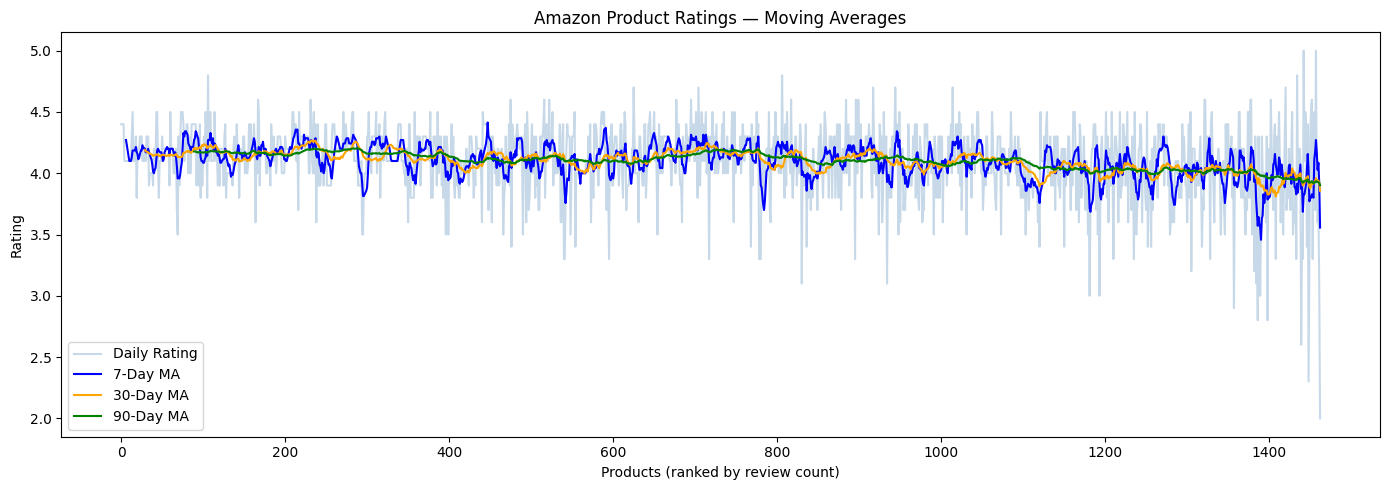

In [3]:
df = df.sort_values('rating_count', ascending=False).reset_index(drop=True)

df['7_day_ma']  = df['rating'].rolling(window=7,  min_periods=7).mean()
df['30_day_ma'] = df['rating'].rolling(window=30, min_periods=30).mean()
df['90_day_ma'] = df['rating'].rolling(window=90, min_periods=90).mean()

plt.figure(figsize=(14,5))
plt.plot(df['rating'],     alpha=0.3, color='steelblue', label='Daily Rating')
plt.plot(df['7_day_ma'],   color='blue',   label='7-Day MA')
plt.plot(df['30_day_ma'],  color='orange', label='30-Day MA')
plt.plot(df['90_day_ma'],  color='green',  label='90-Day MA')
plt.title('Amazon Product Ratings — Moving Averages')
plt.xlabel('Products (ranked by review count)')
plt.ylabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
df['abc_tier'] = pd.qcut(df['rating_count'],
                          q=[0, 0.5, 0.8, 1.0],
                          labels=['C','B','A'])

print(df['abc_tier'].value_counts())
df[['product_name','rating','rating_count','abc_tier']].head(20)

abc_tier
C    733
B    437
A    293
Name: count, dtype: int64


,product_name,rating,rating_count,abc_tier
0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,A
1,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,A
2,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,A
3,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0,A
4,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,A
5,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,A
6,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0,A
7,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",4.1,313836.0,A
8,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0,A
9,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",4.1,313832.0,A


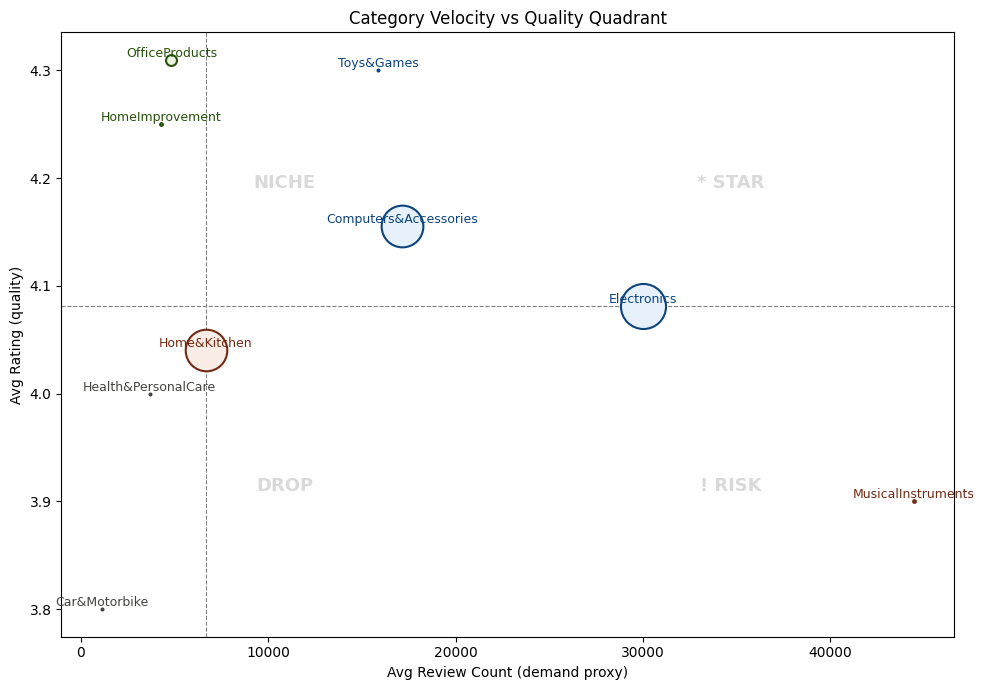

        main_category  avg_rating  avg_reviews quadrant
        Car&Motorbike    3.800000  1118.000000     DROP
Computers&Accessories    4.155654 17136.782705     STAR
          Electronics    4.081749 29997.809886     STAR
  Health&PersonalCare    4.000000  3663.000000     DROP
         Home&Kitchen    4.040402  6676.493304     RISK
      HomeImprovement    4.250000  4283.000000    NICHE
   MusicalInstruments    3.900000 44441.000000     RISK
       OfficeProducts    4.309677  4828.225806    NICHE
           Toys&Games    4.300000 15867.000000     STAR


In [5]:
cats = df.groupby('main_category').agg(
    avg_rating=('rating','mean'),
    avg_reviews=('rating_count','mean'),
    count=('rating','count')
).reset_index()

med_rating  = cats['avg_rating'].median()
med_reviews = cats['avg_reviews'].median()

def quadrant(r, v):
    if r >= med_rating and v >= med_reviews: return 'STAR'
    if r >= med_rating and v <  med_reviews: return 'NICHE'
    if r <  med_rating and v >= med_reviews: return 'RISK'
    return 'DROP'

cats['quadrant'] = cats.apply(lambda x: quadrant(x['avg_rating'], x['avg_reviews']), axis=1)

colors = {'STAR':'#E6F1FB','NICHE':'#EAF3DE','RISK':'#FAECE7','DROP':'#F1EFE8'}
text_colors = {'STAR':'#0C447C','NICHE':'#27500A','RISK':'#712B13','DROP':'#444441'}

fig, ax = plt.subplots(figsize=(10,7))
ax.axvline(med_reviews, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(med_rating,  color='gray', linestyle='--', linewidth=0.8)

for _, row in cats.iterrows():
    q = row['quadrant']
    ax.scatter(row['avg_reviews'], row['avg_rating'],
               s=row['count']*2, color=colors[q], edgecolors=text_colors[q], linewidth=1.5, zorder=3)
    ax.annotate(row['main_category'],
                (row['avg_reviews'], row['avg_rating']),
                fontsize=9, ha='center', va='bottom', color=text_colors[q])

ax.set_xlabel('Avg Review Count (demand proxy)')
ax.set_ylabel('Avg Rating (quality)')
ax.set_title('Category Velocity vs Quality Quadrant')

for label, (x, y) in [('* STAR',(.75,.75)),('NICHE',(.25,.75)),('! RISK',(.75,.25)),('DROP',(.25,.25))]:
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=13, alpha=0.15, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(cats[['main_category','avg_rating','avg_reviews','quadrant']].to_string(index=False))